# SFT training comparison plot

Reproduce the publication-style comparison of the Qwen2.5 0.5B and 3B supervised fine-tuning runs. The figure shows optimization loss, teacher-forced validation loss, and generated-dev BioASQ MRR. Stars identify the checkpoints selected by generated-dev MRR.

This notebook reads completed training artifacts only. It does not load a model, use the GPU, or call an API. The plotted task-performance values are the **training-time 4,096-token checkpoint-selection metrics**, not the separate standardized evaluation-workflow results.


In [10]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "src/notebook_workflows").is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.notebook_workflows.sft_training_plot as sft_training_plot
print("Project:", PROJECT_ROOT)


Project: C:\Users\Dustin\Projects\BioASQ-MRES


## Configuration

Change the labels, run directories, colors, title, or output filename here. Each run must contain `adapter/training_metrics.csv`, `generated_dev_selection/history.json`, and `generated_dev_selection/best_summary.json`.


In [11]:
RUNS = {
    "Qwen2.5 0.5B": (
        PROJECT_ROOT
        / "Artifacts/notebook_runs/sft/answer_sft"
        / "20260927-143545-67f7a338"
    ),
    "Qwen2.5 3B": (
        PROJECT_ROOT
        / "Artifacts/notebook_runs/sft/answer_sft"
        / "20260927-143545-3fca1c3d"
    ),
}
COLORS = {
    "Qwen2.5 0.5B": "#0072B2",
    "Qwen2.5 3B": "#D55E00",
}
TITLE = "Supervised fine-tuning dynamics"
SUBTITLE = "Qwen2.5 factoid extractors | shared 160-question BioASQ development set"
MAX_SEQ_LENGTH = 4096
FONT_SCALE = 1.30
OUTPUT_PATH = PROJECT_ROOT / "Artifacts/plots/sft_qwen25_05b_vs_3b_training_publication.png"

for label, run in RUNS.items():
    if not run.is_dir():
        raise FileNotFoundError(f"Missing {label} run: {run}")
print("Output:", OUTPUT_PATH)


Output: C:\Users\Dustin\Projects\BioASQ-MRES\Artifacts\plots\sft_qwen25_05b_vs_3b_training_publication.png


## Draw and save

The output is a 3,300 x 1,200 PNG saved at 300 DPI. Training loss uses a centered 10-step rolling median with the raw trajectory shown faintly underneath.


,model,run,best_step,best_epoch,best_dev_mrr,dev_questions
0,Qwen2.5 0.5B,C:\Users\Dustin\Projects\BioASQ-MRES\Artifacts...,150,3.493030,0.40625,160
1,Qwen2.5 3B,C:\Users\Dustin\Projects\BioASQ-MRES\Artifacts...,100,2.328687,0.46875,160


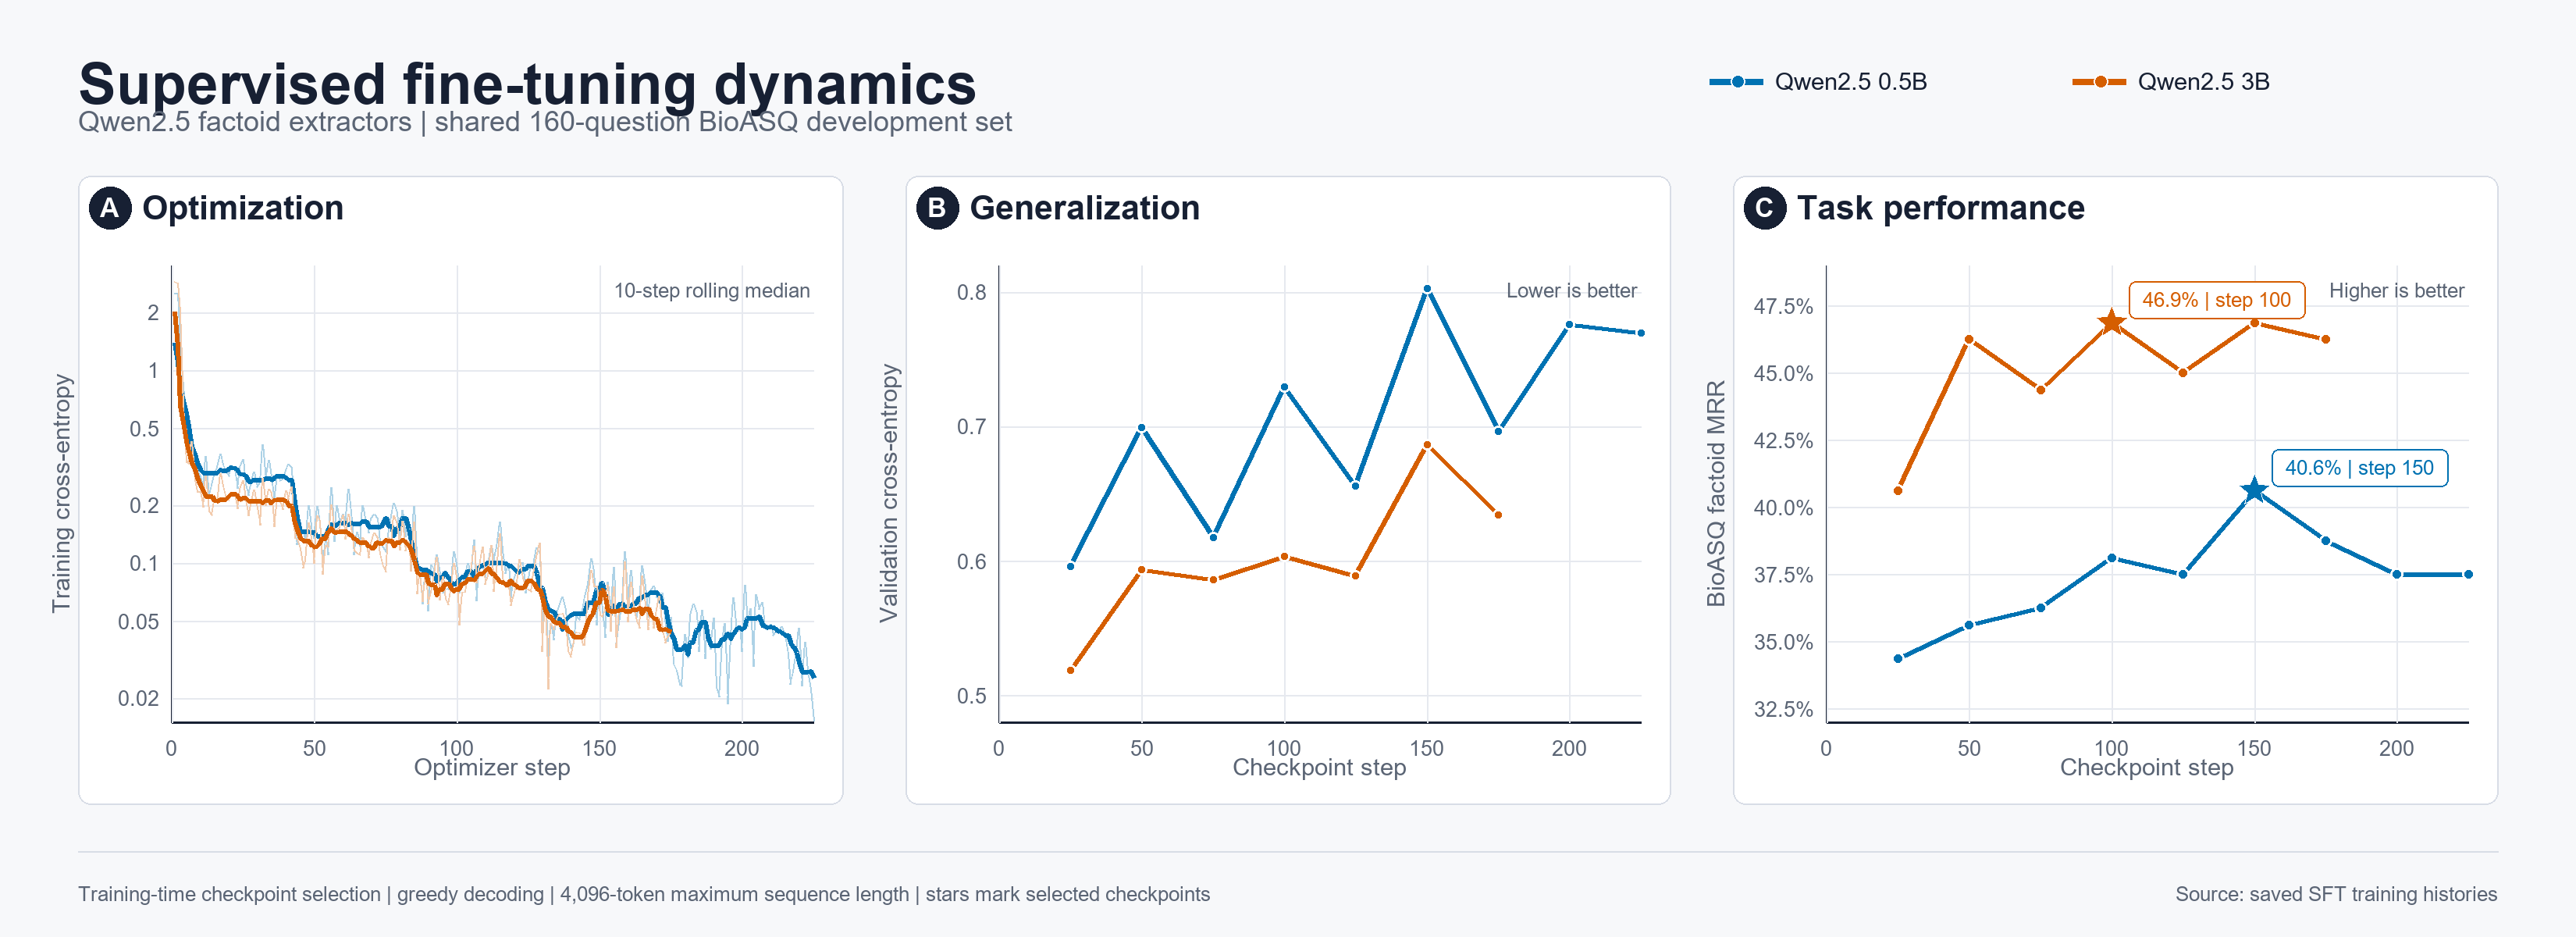

Saved: C:\Users\Dustin\Projects\BioASQ-MRES\Artifacts\plots\sft_qwen25_05b_vs_3b_training_publication.png


In [12]:
# Reload local plotting code so this cell also works after the module is edited.
import importlib
sft_training_plot = importlib.reload(
    importlib.import_module("src.notebook_workflows.sft_training_plot")
)

SUMMARY = sft_training_plot.draw_sft_training_comparison(
    RUNS,
    OUTPUT_PATH,
    colors=COLORS,
    title=TITLE,
    subtitle=SUBTITLE,
    max_seq_length=MAX_SEQ_LENGTH,
    font_scale=FONT_SCALE,
)
display(pd.DataFrame(SUMMARY["runs"]))
display(Image(filename=SUMMARY["output_path"]))
print("Saved:", SUMMARY["output_path"])


## Interpretation

- Panel A shows optimization on the SFT training examples. Lower loss means greater probability assigned to the recorded training targets.
- Panel B is teacher-forced validation cross-entropy. Its increase after early checkpoints indicates worsening calibration or specialization to the training distribution.
- Panel C evaluates actual greedy answers with the BioASQ scorer. This is the metric used to select the saved SFT checkpoints.
- Use the standalone evaluation workflow for final model reporting; this plot documents training and checkpoint selection.
